In [ ]:
%matplotlib inline


Training a Classifier
=====================

This is it. You have seen how to define neural networks, compute loss and make
updates to the weights of the network.

Now you might be thinking,

What about data?
----------------

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a ``torch.*Tensor``.

-  For images, packages such as Pillow, OpenCV are useful
-  For audio, packages such as scipy and librosa
-  For text, either raw Python or Cython based loading, or NLTK and
   SpaCy are useful

Specifically for vision, we have created a package called
``torchvision``, that has data loaders for common datasets such as
Imagenet, CIFAR10, MNIST, etc. and data transformers for images, viz.,
``torchvision.datasets`` and ``torch.utils.data.DataLoader``.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset.
It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of
size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

.. figure:: /_static/img/cifar10.png
   :alt: cifar10

   cifar10


Training an image classifier
----------------------------

We will do the following steps in order:

1. Load and normalizing the CIFAR10 training and test datasets using
   ``torchvision``
2. Define a Convolutional Neural Network
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data

1. Loading and normalizing CIFAR10


Using ``torchvision``, it’s extremely easy to load CIFAR10.



In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

The output of torchvision datasets are PILImage images of range [0, 1].
We transform them to Tensors of normalized range [-1, 1].
<div class="alert alert-info"><h4>Note</h4><p>If running on Windows and you get a BrokenPipeError, try setting
    the num_worker of torch.utils.data.DataLoader() to 0.</p></div>



In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


Let us show some of the training images, for fun.



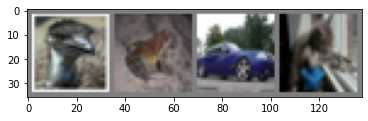

 bird  frog   car   cat


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = dataiter.next()

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

2. Define a Convolutional Neural Network
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Copy the neural network from the Neural Networks section before and modify it to
take 3-channel images (instead of 1-channel images as it was defined).



In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
print(net)
summary(net, (3, 32, 32))

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
         MaxPool2d-2            [-1, 6, 14, 14]               0
            Conv2d-3           [-1, 16, 10, 10]           2,416
         MaxPool2d-4             [-1, 16, 5, 5]               0
            Linear-5                  [-1, 120]          48,120
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 62,006
Trainabl

3. Define a Loss function and optimizer
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Let's use a Classification Cross-Entropy loss and SGD with momentum.



In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

4. Train the network
^^^^^^^^^^^^^^^^^^^^

This is when things start to get interesting.
We simply have to loop over our data iterator, and feed the inputs to the
network and optimize.



In [ ]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.251
[1,  4000] loss: 1.890
[1,  6000] loss: 1.714
[1,  8000] loss: 1.642
[1, 10000] loss: 1.562
[1, 12000] loss: 1.517
[2,  2000] loss: 1.463
[2,  4000] loss: 1.433
[2,  6000] loss: 1.401
[2,  8000] loss: 1.343
[2, 10000] loss: 1.314
[2, 12000] loss: 1.292
Finished Training


Let's quickly save our trained model:



In [ ]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

See `here <https://pytorch.org/docs/stable/notes/serialization.html>`_
for more details on saving PyTorch models.

5. Test the network on the test data
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

We have trained the network for 2 passes over the training dataset.
But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.



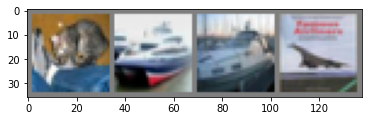

GroundTruth:    cat  ship  ship plane


In [ ]:
dataiter = iter(testloader)
images, labels = dataiter.next()

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

Next, let's load back in our saved model (note: saving and re-loading the model
wasn't necessary here, we only did it to illustrate how to do so):



In [ ]:
net = Net()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above are:



In [ ]:
outputs = net(images)
print(outputs)

tensor([[-1.0527, -2.0392,  0.5256,  2.0137,  0.2830,  1.2946,  1.6625, -0.5614,
         -1.6706, -1.4262],
        [ 5.4497,  5.3380, -1.8786, -2.5017, -1.6988, -5.0074, -5.5323, -3.0740,
          4.4523,  3.4945],
        [ 2.9393,  2.6709, -0.4014, -1.0776, -0.5254, -2.6968, -2.7027, -2.2879,
          2.4863,  0.7938],
        [ 6.5563,  1.4135,  0.5254, -1.5467, -0.0764, -4.3833, -3.5636, -3.8858,
          6.1303,  0.1613]], grad_fn=<AddmmBackward>)


The outputs are energies for the 10 classes.
The higher the energy for a class, the more the network
thinks that the image is of the particular class.
So, let's get the index of the highest energy:



In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))

Predicted:    cat plane plane plane


The results seem pretty good.

Let us look at how the network performs on the whole dataset.



In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 54 %


That looks way better than chance, which is 10% accuracy (randomly picking
a class out of 10 classes).
Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:



In [ ]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 75 %
Accuracy of   car : 68 %
Accuracy of  bird : 41 %
Accuracy of   cat : 32 %
Accuracy of  deer : 44 %
Accuracy of   dog : 33 %
Accuracy of  frog : 81 %
Accuracy of horse : 54 %
Accuracy of  ship : 51 %
Accuracy of truck : 57 %


# Evaluation of the model

Then, let's make the confusion matrix.

In [ ]:
# Cell 1

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
gt = []
pred = []
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        pred += [classes[i] for i in predicted.tolist()]
        gt += [classes[i] for i in labels.tolist()]

# View first 20 labels and predictions.
print(gt[:20])
print(pred[:20])

['cat', 'ship', 'ship', 'plane', 'frog', 'frog', 'car', 'frog', 'cat', 'car', 'plane', 'truck', 'dog', 'horse', 'truck', 'ship', 'dog', 'horse', 'ship', 'frog']
['cat', 'plane', 'plane', 'plane', 'frog', 'frog', 'bird', 'frog', 'cat', 'car', 'plane', 'truck', 'frog', 'horse', 'truck', 'plane', 'dog', 'cat', 'ship', 'frog']


[[757  78 135  68  64  37  13  56 299  89]
 [ 42 684  11  15  12  11  13  14  64 180]
 [ 57  11 415 109 169 141  50  66  23  16]
 [  6  11  63 324  51 204  32  55  20  18]
 [ 16   8 112  87 440  67  42 124   7   9]
 [  3   5  43 101  25 337  20  59   7   8]
 [ 34  31 172 215 164 114 814  42  18  35]
 [  6  11  27  39  54  67   8 545   4  30]
 [ 52  38  17  11  18  13   2   9 519  36]
 [ 27 123   5  31   3   9   6  30  39 579]]


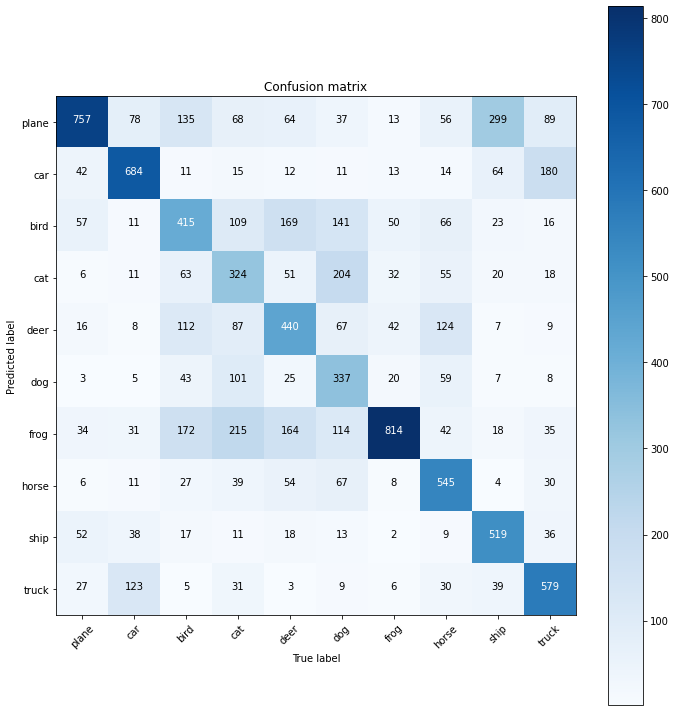

In [ ]:
# Cell 2
# https://datascience.stackexchange.com/questions/40067/confusion-matrix-three-classes-python

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools

# Define confusion matrix plot function.

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Predicted label')
    plt.xlabel('True label')
    plt.tight_layout()

# Using the defined function above, build confusion matrix.
# cnf_matrix = confusion_matrix(gt, pred,labels=list(classes))
cnf_matrix = confusion_matrix(pred, gt,labels=list(classes))

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=list(classes),
                      title='Confusion matrix')
plt.savefig('Model_1_confusion_matrix',dpi=300);

Let's find precision and recall.

In [ ]:
# Cell 3

from sklearn.metrics import precision_recall_fscore_support as score

precision, recall, fscore, support = score(gt, pred)

print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))


precision: [0.39262062 0.65391969 0.41326531 0.48245614 0.55427632 0.4966443
 0.68900126 0.47431078 0.72587413 0.67957746]
recall: [0.415 0.684 0.324 0.44  0.337 0.814 0.545 0.757 0.519 0.579]
fscore: [0.40350024 0.6686217  0.3632287  0.46025105 0.41915423 0.61690034
 0.60859855 0.58320493 0.60524781 0.62526998]
support: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


In [ ]:
# Cell 4

from sklearn.metrics import classification_report

print(classification_report(gt, pred, target_names=list(classes)))

              precision    recall  f1-score   support

       plane       0.39      0.41      0.40      1000
         car       0.65      0.68      0.67      1000
        bird       0.41      0.32      0.36      1000
         cat       0.48      0.44      0.46      1000
        deer       0.55      0.34      0.42      1000
         dog       0.50      0.81      0.62      1000
        frog       0.69      0.55      0.61      1000
       horse       0.47      0.76      0.58      1000
        ship       0.73      0.52      0.61      1000
       truck       0.68      0.58      0.63      1000

    accuracy                           0.54     10000
   macro avg       0.56      0.54      0.54     10000
weighted avg       0.56      0.54      0.54     10000



In [ ]:
# Cell 5

# https://towardsdatascience.com/confusion-matrix-for-your-multi-class-machine-learning-model-ff9aa3bf7826

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('\nAccuracy: {:.2f}\n'.format(accuracy_score(gt, pred)))

print('Micro Precision: {:.2f}'.format(precision_score(gt, pred, average='micro')))
print('Micro Recall: {:.2f}'.format(recall_score(gt, pred, average='micro')))
print('Micro F1-score: {:.2f}\n'.format(f1_score(gt, pred, average='micro')))

print('Macro Precision: {:.2f}'.format(precision_score(gt, pred, average='macro')))
print('Macro Recall: {:.2f}'.format(recall_score(gt, pred, average='macro')))
print('Macro F1-score: {:.2f}\n'.format(f1_score(gt, pred, average='macro')))



Accuracy: 0.54

Micro Precision: 0.54
Micro Recall: 0.54
Micro F1-score: 0.54

Macro Precision: 0.56
Macro Recall: 0.54
Macro F1-score: 0.54





*   Micro

It is calculated by considering the total TP, total FP and total FN of the model. It does not consider each class individually, It calculates the metrics globally.

*   Macro

It calculates metrics for each class individually and then takes unweighted mean of the measures.



*   Difference betwen micro and macro average is minimal in a balanced dataset.

ROC and AUC

ROC curve is only for binary classfication problem.

But it can be extended to multiclass classification through One vs All technique.

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:23: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:44: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead


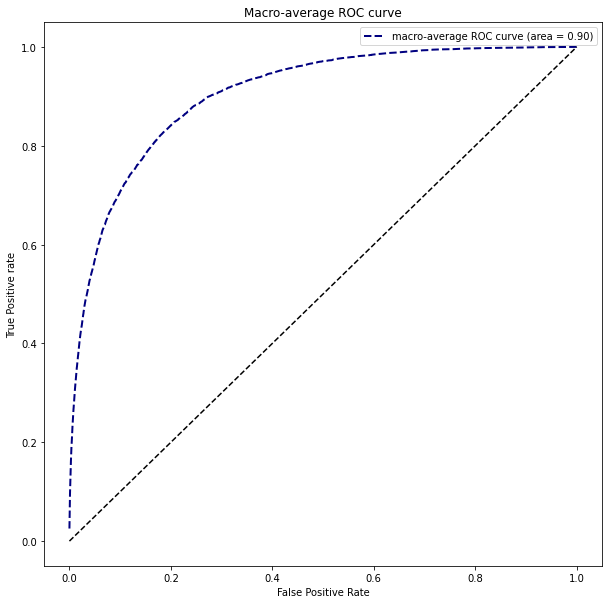

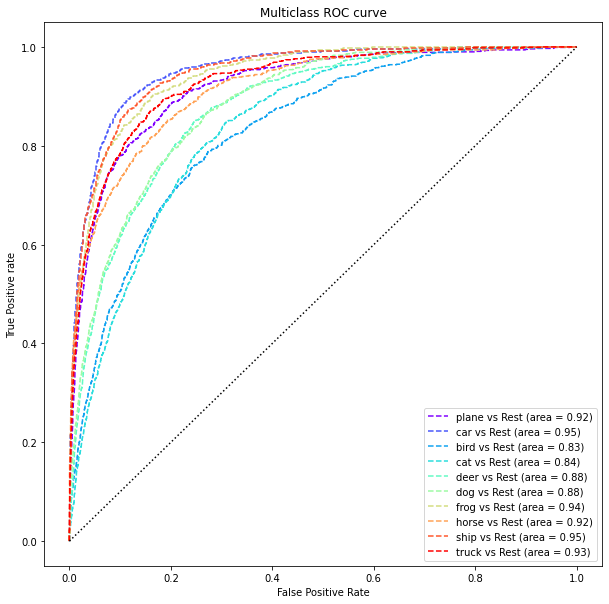

In [ ]:
# Cell 6

# https://www.analyticsvidhya.com/blog/2020/06/auc-roc-curve-machine-learning/#:~:text=Like%20I%20said%20before%2C%20the,0%2C%20i.e.%201%20and%202.
# https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html
# multi-class classification

from sklearn.metrics import roc_curve, auc
from matplotlib.pyplot import cm
from scipy import interp

softmax = nn.Softmax()

n_classes = len(classes)

gt = []
pred_prob = []

with torch.no_grad():
    for data in testloader:
        images, labels = data
        gt += labels.tolist()
        outputs = net(images)
        outputs_prob = softmax(outputs)
        pred_prob += outputs_prob.tolist()

pred_prob = np.array(pred_prob)

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], thresh[i] = roc_curve(gt, pred_prob[:,i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Finding macro roc and auc for model
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# plotting
plt.figure(num=1, figsize=(10, 10))
plt.plot(fpr["macro"], tpr["macro"], label='macro-average ROC curve (area = {0:0.2f})'.format(roc_auc["macro"]),
         color='navy', linestyle='--', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Macro-average ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Macro-average ROC Model 1',dpi=300);

plt.figure(num=2, figsize=(10, 10))
color=iter(cm.rainbow(np.linspace(0,1,n_class)))
for i in range(n_class):
  # plt.figure(num=i)
  plt.plot(fpr[i], tpr[i], linestyle='--',color=next(color), label='{} vs Rest (area = {:0.2f})'.format(classes[i], roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k:')
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Multiclass ROC Model 1',dpi=300);

# Build new model and compare with the model above.

In [ ]:
# Cell 7

import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

# Addition of a convolutional layer and implement a dropout
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout2d(p=0.1)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.conv3 = nn.Conv2d(16, 30, 3)
        self.fc1 = nn.Linear(30 * 1 * 1, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(self.dropout(F.relu(self.conv3(x))))
        # print(x.shape)
        x = x.view(-1, 30 * 1 * 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


mynet = MyNet()
print(mynet)
summary(mynet, (3, 32, 32))

MyNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout2d(p=0.1, inplace=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 30, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=30, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
         MaxPool2d-2            [-1, 6, 14, 14]               0
            Conv2d-3           [-1, 16, 10, 10]           2,416
         MaxPool2d-4             [-1, 16, 5, 5]               0
            Conv2d-5             [-1, 30, 3, 3]           4,350
         Dropout2d-6             [-1, 30, 3, 3]   

In [ ]:
# Cell 8

# Train mynet

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mynet.parameters(), lr=0.001, momentum=0.9)

for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = mynet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

PATH = './cifar_mynet.pth'
torch.save(mynet.state_dict(), PATH)

[1,  2000] loss: 2.303
[1,  4000] loss: 2.277
[1,  6000] loss: 2.011
[1,  8000] loss: 1.889
[1, 10000] loss: 1.761
[1, 12000] loss: 1.726
[2,  2000] loss: 1.641
[2,  4000] loss: 1.607
[2,  6000] loss: 1.583
[2,  8000] loss: 1.555
[2, 10000] loss: 1.548
[2, 12000] loss: 1.537
Finished Training


In [ ]:
# Cell 9

# import pdb; pdb.set_trace()

mynet_trained = MyNet()
mynet_trained.load_state_dict(torch.load(PATH))

correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = mynet_trained(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = mynet(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of the network on the 10000 test images: 44 %
Accuracy of plane : 56 %
Accuracy of   car : 33 %
Accuracy of  bird : 16 %
Accuracy of   cat : 31 %
Accuracy of  deer : 31 %
Accuracy of   dog : 44 %
Accuracy of  frog : 52 %
Accuracy of horse : 62 %
Accuracy of  ship : 51 %
Accuracy of truck : 63 %


In [ ]:
# Cell 10

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
gt = []
pred = []
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = mynet_trained(images)
        _, predicted = torch.max(outputs, 1)

        pred += [classes[i] for i in predicted.tolist()]
        gt += [classes[i] for i in labels.tolist()]


[[557  71  96  37  52  24   7  27 270  53]
 [ 16 335   7   7   5   4   8   3  26  66]
 [ 38   4 158  37  43  37  28  15  10   3]
 [ 17  16 132 318 112 207 138  79  28  24]
 [ 25   8 201  51 305  48 138  42  17   6]
 [  7   6 106 216  49 427  26 114  10  11]
 [ 14  13  96 113 135  42 528  23   7  23]
 [ 57  34 150 150 255 170  85 615  21  70]
 [191 165  27  16  22  11  12  10 505 108]
 [ 78 348  27  55  22  30  30  72 106 636]]


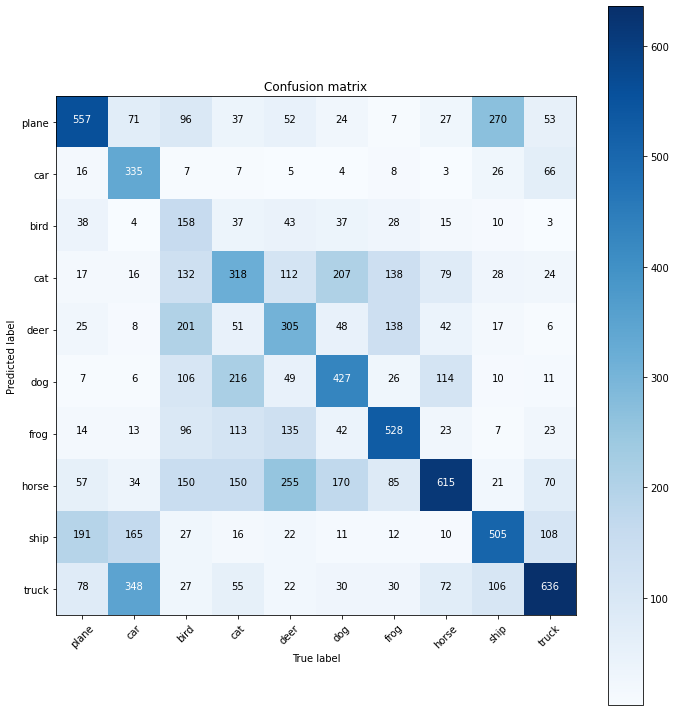

In [ ]:
# Cell 11

cnf_matrix = confusion_matrix(pred, gt,labels=list(classes))

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=list(classes),
                      title='Confusion matrix')
plt.savefig('MyNet_confusion_matrix',dpi=300);

In [ ]:
# Cell 12

from sklearn.metrics import classification_report
print(classification_report(gt, pred, target_names=list(classes)))

              precision    recall  f1-score   support

       plane       0.42      0.16      0.23      1000
         car       0.70      0.34      0.45      1000
        bird       0.30      0.32      0.31      1000
         cat       0.36      0.30      0.33      1000
        deer       0.44      0.43      0.43      1000
         dog       0.53      0.53      0.53      1000
        frog       0.38      0.61      0.47      1000
       horse       0.47      0.56      0.51      1000
        ship       0.47      0.51      0.49      1000
       truck       0.45      0.64      0.53      1000

    accuracy                           0.44     10000
   macro avg       0.45      0.44      0.43     10000
weighted avg       0.45      0.44      0.43     10000



In [ ]:
# https://towardsdatascience.com/confusion-matrix-for-your-multi-class-machine-learning-model-ff9aa3bf7826

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('\nAccuracy: {:.2f}\n'.format(accuracy_score(gt, pred)))

print('Micro Precision: {:.2f}'.format(precision_score(gt, pred, average='micro')))
print('Micro Recall: {:.2f}'.format(recall_score(gt, pred, average='micro')))
print('Micro F1-score: {:.2f}\n'.format(f1_score(gt, pred, average='micro')))

print('Macro Precision: {:.2f}'.format(precision_score(gt, pred, average='macro')))
print('Macro Recall: {:.2f}'.format(recall_score(gt, pred, average='macro')))
print('Macro F1-score: {:.2f}\n'.format(f1_score(gt, pred, average='macro')))



Accuracy: 0.45

Micro Precision: 0.45
Micro Recall: 0.45
Micro F1-score: 0.45

Macro Precision: 0.44
Macro Recall: 0.45
Macro F1-score: 0.44



/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:24: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:45: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead


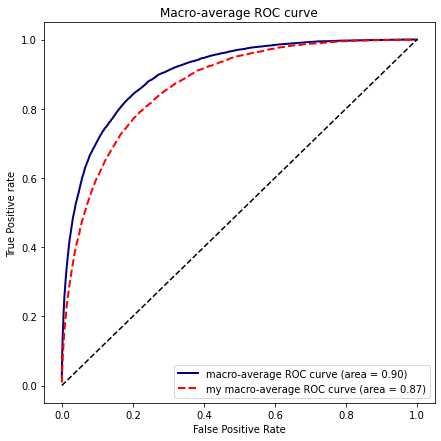

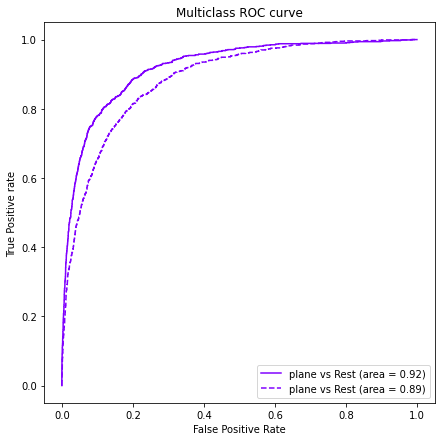

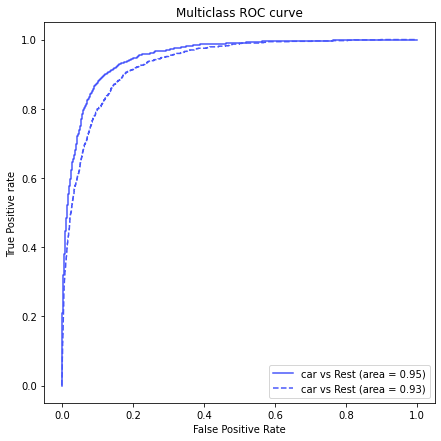

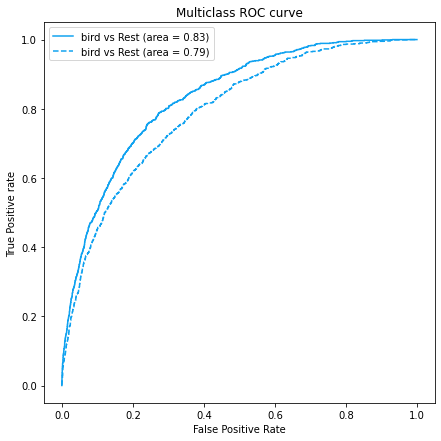

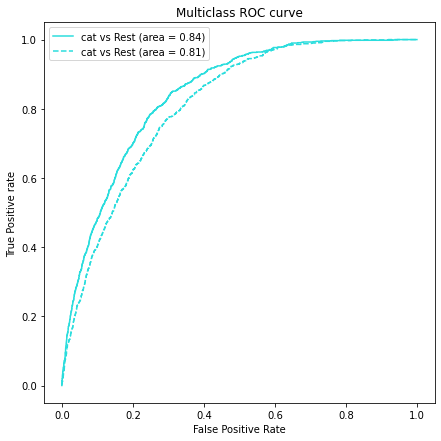

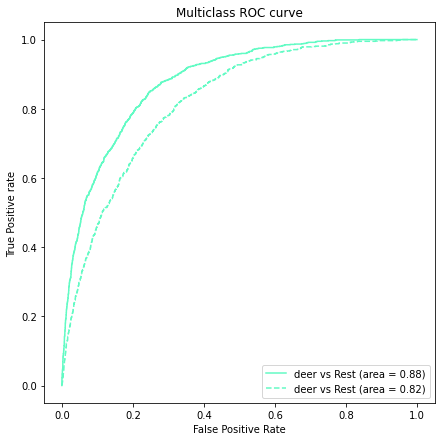

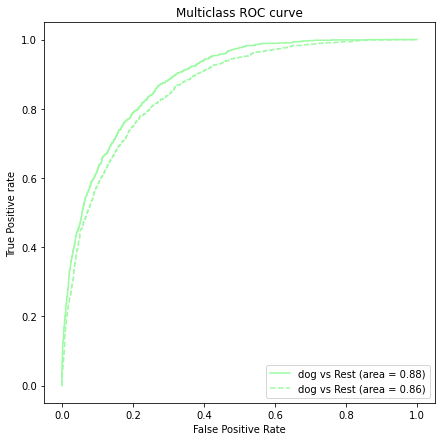

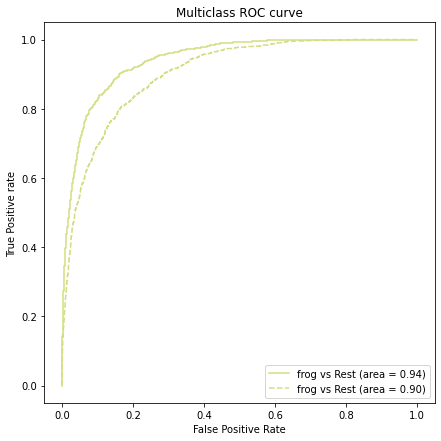

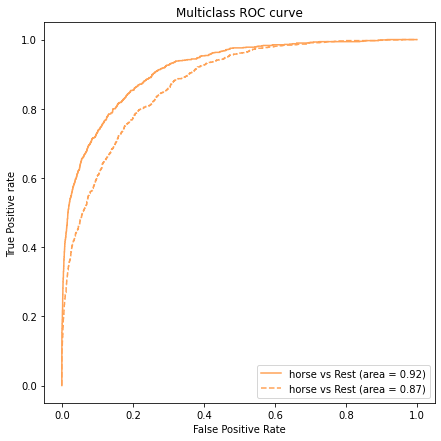

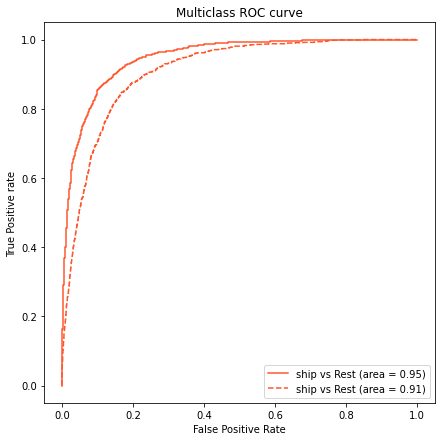

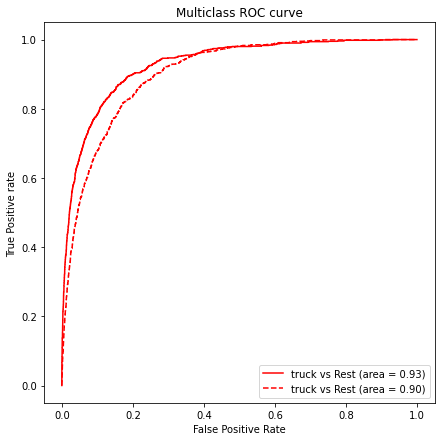

In [ ]:
# Cell 13

# https://www.analyticsvidhya.com/blog/2020/06/auc-roc-curve-machine-learning/#:~:text=Like%20I%20said%20before%2C%20the,0%2C%20i.e.%201%20and%202.
# multi-class classification
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib.pyplot import cm

softmax = nn.Softmax()

n_class = len(classes)

gt = []
pred_prob = []

with torch.no_grad():
    for data in testloader:
        images, labels = data
        gt += labels.tolist()
        outputs = mynet_trained(images)
        outputs_prob = softmax(outputs)
        pred_prob += outputs_prob.tolist()

pred_prob = np.array(pred_prob)

# roc curve for classes
fpr_my = {}
tpr_my = {}
thresh_my ={}
roc_auc_my = {}

for i in range(n_class):
    fpr_my[i], tpr_my[i], thresh_my[i] = roc_curve(gt, pred_prob[:,i], pos_label=i)
    roc_auc_my[i] = auc(fpr_my[i], tpr_my[i])

# Finding macro roc and auc for model
all_fpr = np.unique(np.concatenate([fpr_my[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr_my[i], tpr_my[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr_my["macro"] = all_fpr
tpr_my["macro"] = mean_tpr
roc_auc_my["macro"] = auc(fpr_my["macro"], tpr_my["macro"])

# plotting
plt.figure(num=0, figsize=(7, 7))
plt.plot(fpr["macro"], tpr["macro"], label='macro-average ROC curve (area = {0:0.2f})'.format(roc_auc["macro"]),
         color='navy', linestyle='-', linewidth=2)
plt.plot(fpr_my["macro"], tpr_my["macro"], label='my macro-average ROC curve (area = {0:0.2f})'.format(roc_auc_my["macro"]),
         color='red', linestyle='--', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Macro-average ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Macro average ROC Comparison',dpi=300);

color=iter(cm.rainbow(np.linspace(0,1,n_class)))
for i in range(n_class):
  plt.figure(num=i + 1, figsize=(7, 7))
  c = next(color)
  plt.plot(fpr[i], tpr[i], linestyle='-',color=c, label='{} vs Rest (area = {:0.2f})'.format(classes[i], roc_auc[i]))
  plt.plot(fpr_my[i], tpr_my[i], linestyle='--',color=c, label='{} vs Rest (area = {:0.2f})'.format(classes[i], roc_auc_my[i]))

  plt.title('Multiclass ROC curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive rate')
  plt.legend(loc='best')
  plt.savefig('Multiclass ROC comparison {}'.format(i),dpi=300);

In [ ]:
# Cell 14
# https://pytorch.org/docs/stable/torchvision/models.html#id2

import torchvision

vgg_model = torchvision.models.vgg16(pretrained=True)
print(vgg_model)

summary(vgg_model, (3, 32, 32))


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth



VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

In [ ]:
# Cell 15
# Change the last layer
for param in vgg_model.parameters():
    param.requires_grad = False

vgg_model.classifier._modules['6'] = nn.Linear(4096, 10)

summary(vgg_model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]          36,928
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
            Conv2d-6          [-1, 128, 16, 16]          73,856
              ReLU-7          [-1, 128, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]         147,584
              ReLU-9          [-1, 128, 16, 16]               0
        MaxPool2d-10            [-1, 128, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         295,168
             ReLU-12            [-1, 256, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         590,080
             ReLU-14            [-1, 25

In [ ]:
# Try on GPU, CPU too slow
# Train vgg_model

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_model.parameters(), lr=0.001, momentum=0.9)

for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = vgg_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

PATH = './cifar_vgg_model.pth'
torch.save(vgg_model.state_dict(), PATH)

vgg_trained = torchvision.models.vgg11(pretrained=False)
vgg_model.classifier._modules['6'] = nn.Linear(4096, 10)
vgg_trained.load_state_dict(torch.load(PATH))

correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = vgg_trained(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

KeyboardInterrupt: ignored

Okay, so what next?

How do we run these neural networks on the GPU?

# Training on GPU
----------------
Just like how you transfer a Tensor onto the GPU, you transfer the neural
net onto the GPU.

Let's first define our device as the first visible cuda device if we have
CUDA available:



In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cpu


The rest of this section assumes that ``device`` is a CUDA device.

Then these methods will recursively go over all modules and convert their
parameters and buffers to CUDA tensors:

.. code:: python

    net.to(device)


Remember that you will have to send the inputs and targets at every step
to the GPU too:

.. code:: python

        inputs, labels = data[0].to(device), data[1].to(device)

Why dont I notice MASSIVE speedup compared to CPU? Because your network
is really small.

**Exercise:** Try increasing the width of your network (argument 2 of
the first ``nn.Conv2d``, and argument 1 of the second ``nn.Conv2d`` –
they need to be the same number), see what kind of speedup you get.

**Goals achieved**:

- Understanding PyTorch's Tensor library and neural networks at a high level.
- Train a small neural network to classify images

Training on multiple GPUs
-------------------------
If you want to see even more MASSIVE speedup using all of your GPUs,
please check out :doc:`data_parallel_tutorial`.

Where do I go next?
-------------------

-  :doc:`Train neural nets to play video games </intermediate/reinforcement_q_learning>`
-  `Train a state-of-the-art ResNet network on imagenet`_
-  `Train a face generator using Generative Adversarial Networks`_
-  `Train a word-level language model using Recurrent LSTM networks`_
-  `More examples`_
-  `More tutorials`_
-  `Discuss PyTorch on the Forums`_
-  `Chat with other users on Slack`_


